# **Section 2: CNV Feature Selection**

This notebook imports the CNV feature matrix, merges it with the metadata containing the resistance profile of each strain and performs feature selection. 

**Overview:**
1. Load cnv data and resistance phenotypes
2. Merge data on sample name
3. Remove duplicate features (identical across all samples)
4. Remove highly correlated features
5. Select features using SelectKBest (f_classif scoring)
6. Save cleaned feature matrix ready for ML

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.preprocessing import StandardScaler

# Set pastel color palette for plots
sns.set_palette("pastel")

In [2]:
# Select antibiotic
target_antibiotic = 'SXT'

# Define paths:
cnv_tsv = "../cnv_ML/cnv_filtered.tsv"
resistance_profiles = "../genome_metadata.csv"

## **0. Helper functions**
The function **parse_resistance_profile** is used to extract the resistance profiles from the genome_metadata.csv file.

In [3]:
def parse_resistance_profile(profile_str):
    """
    Parse resistance profile string into individual antibiotic phenotypes.

    Format: "Resistant to X, Y; Susceptible to A, B; Intermediate to C; Not determined: D"
    Returns: dict with antibiotic: phenotype (R/S/I/ND)
    """
    phenotypes = {}
    
    if pd.isna(profile_str):
        return phenotypes
    
    # Split by semicolon to get phenotype groups
    parts = str(profile_str).split(';')
    
    for part in parts:
        part = part.strip()
        if not part:
            continue
            
        # Determine phenotype
        if part.startswith('Resistant to'):
            phenotype = 'R'
            antibiotics_str = part.replace('Resistant to', '').strip()
        elif part.startswith('Susceptible to'):
            phenotype = 'S'
            antibiotics_str = part.replace('Susceptible to', '').strip()
        elif part.startswith('Intermediate to'):
            phenotype = 'I'
            antibiotics_str = part.replace('Intermediate to', '').strip()
        elif part.startswith('Not determined'):
            phenotype = 'ND'
            antibiotics_str = part.replace('Not determined:', '').strip()
        else:
            continue
        
        # Split antibiotics by comma and add to dict
        antibiotics = [ab.strip() for ab in antibiotics_str.split(',')]
        for antibiotic in antibiotics:
            if antibiotic:
                phenotypes[antibiotic] = phenotype
    
    return phenotypes

## **1. Load and preprocess the data**
We first want to load the feature matrix (containing detected CNVs for all the strains) and a metadata file containing the resistance profile for all strains. 
We will then make sure that the strains in the feature matrix have a corresponding resistance profile.

### **1.1 Load CNV feature matrix and resistance profiles**

In [4]:
# Load CNV feature matrix
cnv_df = pd.read_csv(cnv_tsv, sep='\t', index_col=0)
print(f"CNV feature matrix shape: {cnv_df.shape}")
cnv_df.head()

CNV feature matrix shape: (221, 23338)


,cnv_depth__IBNLCO_00001__IBNLCO_00001__gene,cnv_depth__unknown__unknown__source,cnv_depth__IBNLCO_00001__Putative__CDS,cnv_depth__IBNLCO_00001__IBNLCO_00001__gene__promoter,cnv_depth__IBNLCO_00001__Putative__CDS__promoter,cnv_depth__IBNLCO_00002__IBNLCO_00002__gene,cnv_depth__IBNLCO_00002__Cation/H+__CDS,cnv_depth__IBNLCO_00002__Cation/H+__CDS__promoter,cnv_depth__IBNLCO_00002__IBNLCO_00002__gene__promoter,cnv_depth__IBNLCO_00003__tRNA__CDS,...,cnv_depth__IBNLCO_05853__IBNLCO_05853__gene,cnv_depth__IBNLCO_05853__Nucleoid__CDS,cnv_depth__IBNLCO_05854__IBNLCO_05854__gene,cnv_depth__IBNLCO_05854__Initiator__CDS,cnv_depth__IBNLCO_05854__IBNLCO_05854__gene__promoter,cnv_depth__IBNLCO_05854__Initiator__CDS__promoter,cnv_depth__IBNLCO_05855__IBNLCO_05855__gene,cnv_depth__IBNLCO_05855__hypothetical__CDS,cnv_depth__IBNLCO_05855__IBNLCO_05855__gene__promoter,cnv_depth__IBNLCO_05855__hypothetical__CDS__promoter
sample,,,,,,,,,,,,,,,,,,,,,
SRR3404582,0.456210,-0.064161,0.456210,0.344561,0.344561,0.072854,0.072854,0.546083,0.546083,0.267388,...,-0.373267,-0.373267,0.143766,0.143766,0.353816,0.353816,0.770642,0.770642,0.328191,0.328191
SRR3404597,0.501361,-0.049432,0.501361,0.319320,0.319320,0.189164,0.189164,0.541349,0.541349,0.287937,...,-0.406352,-0.406352,-0.099969,-0.099969,0.122482,0.122482,0.441589,0.441589,-0.101593,-0.101593
SRR3404599,0.456717,-0.061306,0.456717,0.262671,0.262671,0.119334,0.119334,0.530473,0.530473,0.208922,...,-0.368799,-0.368799,0.014885,0.014885,0.287339,0.287339,0.731126,0.731126,0.359241,0.359241
SRR5927082,0.365460,-0.097766,0.365460,0.188572,0.188572,0.207752,0.207752,0.505214,0.505214,-0.047895,...,-0.334186,-0.334186,0.066785,0.066785,0.169225,0.169225,0.117027,0.117027,-0.709921,-0.709921
SRR6075123,0.481897,-0.087126,0.481897,0.484432,0.484432,0.209904,0.209904,0.319695,0.319695,0.170319,...,-0.048866,-0.048866,0.027058,0.027058,0.120249,0.120249,0.506042,0.506042,-0.061710,-0.061710


In [5]:
# Load resistance profiles
resistances = pd.read_csv(resistance_profiles)
print(f"Sample metadata shape: {resistances.shape}")
resistances.head()

Sample metadata shape: (283, 5)


,genome_name,source,species,resistance_profile,sra_accession
0,EPAC004,Patient,B. pseudomallei,"Resistant to SXT; Susceptible to AMC, CAZ; Not...",SRR27387708
1,EPAC006,Patient,B. pseudomallei,"Resistant to SXT; Susceptible to AMC, CAZ, IPM",SRR27387706
2,EPAC013,Patient,B. pseudomallei,"Resistant to SXT; Susceptible to AMC, CAZ, IPM",SRR27387705
3,EPAC021,Patient,B. pseudomallei,"Resistant to SXT; Susceptible to AMC, CAZ, IPM",SRR27387702
4,EPAC023,Patient,B. pseudomallei,"Resistant to SXT; Susceptible to AMC, CAZ, IPM",SRR27387701


### **1.2 Parse resistance profiles**
We will now parse the resistance profiles into a dictionary using the function parse_resistance_profile defined above. 
The list of dictionaries is then converted into a data frame which contains resistance information for each sample.

In [6]:
# Parse resistance profiles into a dictionary with antibiotic phenotypes
parsed_resistances = resistances['resistance_profile'].apply(parse_resistance_profile)
print(f"\nDictionary list structure: \n")
print(parsed_resistances.head())

# Convert list of dictionaries into a DataFrame
resistances_df = pd.json_normalize(parsed_resistances)
print(f"\nResistance data frame structure: \n")
print(resistances_df.head())

# Add sample name (sra_accession) to data frame and set is as index
resistances_df['sra_accession'] = resistances['sra_accession'].values
resistances_df = resistances_df.set_index('sra_accession')

print(f"\nResistance data frame shape: {resistances_df.shape}")


Dictionary list structure: 

0    {'SXT': 'R', 'AMC': 'S', 'CAZ': 'S', 'IPM': 'ND'}
1     {'SXT': 'R', 'AMC': 'S', 'CAZ': 'S', 'IPM': 'S'}
2     {'SXT': 'R', 'AMC': 'S', 'CAZ': 'S', 'IPM': 'S'}
3     {'SXT': 'R', 'AMC': 'S', 'CAZ': 'S', 'IPM': 'S'}
4     {'SXT': 'R', 'AMC': 'S', 'CAZ': 'S', 'IPM': 'S'}
Name: resistance_profile, dtype: object

Resistance data frame structure: 

  SXT AMC CAZ IPM  MEM   TZ TMEM/SMX
0   R   S   S  ND  NaN  NaN      NaN
1   R   S   S   S  NaN  NaN      NaN
2   R   S   S   S  NaN  NaN      NaN
3   R   S   S   S  NaN  NaN      NaN
4   R   S   S   S  NaN  NaN      NaN

Resistance data frame shape: (283, 7)


### **1.3 Find common samples between feature matrix and resistance profiles**
Let's now filter the CNV feature matrix and the resistance profile data frames so that they only contain common samples

In [7]:
# Find common samples between CNV data and resistance profile data and keep only common samples
# Start by removing duplicate entries
resistances_df = resistances_df.loc[~resistances_df.index.duplicated(keep='first')]
cnv_df = cnv_df.loc[~cnv_df.index.duplicated(keep='first')]

# Find common samples
common_samples = cnv_df.index.intersection(resistances_df.index)
print(f"\nCommon samples: {len(common_samples)} out of {len(cnv_df)} CNV samples and {len(resistances_df)} samples with known resistance profiles")

# Keep only samples with both CNV and phenotype data
cnv_df = cnv_df.loc[common_samples]
resistances_df = resistances_df.loc[common_samples]

print(f"\nMerged data shape:")
print(f"CNVs: {cnv_df.shape}")
print(f"Resistance profiles: {resistances_df.shape}")


Common samples: 221 out of 221 CNV samples and 262 samples with known resistance profiles

Merged data shape:
CNVs: (221, 23338)
Resistance profiles: (221, 7)


### **1.4 Filter feature matrix according to resistance profile**
Let's now go back to our feature matrix and make sure all samples have valid information for the SXT antibiotic. I will also create a binary category for that antibiotic (Susceptible = 0, Resistant = 1).

In [8]:
# Create binary target: S=0 (susceptible), R=1 (resistant)
SXT_profile = resistances_df[target_antibiotic].copy()

# Remove ND 
valid_samples = SXT_profile[SXT_profile.isin(['S', 'R'])].index
print(f"Valid samples: {len(valid_samples)} out of {len(SXT_profile)}")

# Filter feature matrix
cnv_df = cnv_df.loc[valid_samples]

# Convert resistance profile to int (1=Resistant, 0=Susceptible)
SXT_profile = (SXT_profile.loc[valid_samples] == 'R').astype(int) 

print(f"\nFinal dataset:")
print(f"Samples: {len(cnv_df)}")
print(f"CNVs: {cnv_df.shape[1]}")
print(f"\nSXT resistance distribution:\n{SXT_profile.value_counts()}")

Valid samples: 221 out of 221

Final dataset:
Samples: 221
CNVs: 23338

SXT resistance distribution:
SXT
1    119
0    102
Name: count, dtype: int64


## **2. Feature Selection**
Now that we have our feature matrix and the resistance profile for all of the strains, let's perform feature selection using SelectKBest.

### **2.1. Remove Duplicate Features**
I will start by removing duplicated features.

In [9]:
# Find duplicate CNVs
cnv_T = cnv_df.T
duplicates = cnv_T.duplicated(keep='first')

print(f"Number of duplicated features: {duplicates.sum()}")

# Remove duplicate CNVs
cnv_unique = cnv_df.loc[:, ~duplicates].copy()

print(f"\nAfter removing duplicates:")
print(f"  features before: {cnv_df.shape[1]}")
print(f"  features after: {cnv_unique.shape[1]}")
print(f"  removed: {cnv_df.shape[1] - cnv_unique.shape[1]} CNVs")

Number of duplicated features: 11619

After removing duplicates:
  features before: 23338
  features after: 11719
  removed: 11619 CNVs


We see that a lot of the features were duplications of each other. This comes from how the cnv matrix is created and how GenBank annotations are created. There typically is an annotation for the whole **gene** region and an nearly identical annotation for the **coding sequence (CDS)**. This type of region annotation thus creates nearly identical features (especially in bacteria where gene and coding regions are typically almost identical).

### **2.2 Removing Highly Correlated Features**
I will set a threshold and remove any feature that has a correlation above 99% with another feature. I will always remove the feature that has the least variance in a correlated pair. Highly correlated features do not provide much additional information for a machine learning algorithm.

In [10]:
print(f"Computing feature correlations for {len(cnv_unique.columns)} CNVs")
print("(Processing in batches to avoid memory issues)")

high_corr_pairs = []
cnv_array = cnv_unique.values.astype(np.float32)
n_cnv = cnv_array.shape[1]

# Process in batches
batch_size = 500
for batch_start in range(0, n_cnv, batch_size):
    batch_end = min(batch_start + batch_size, n_cnv)
    
    # Compute correlations for this batch against all CNVs
    batch = cnv_array[:, batch_start:batch_end]
    
    # Normalize for correlation calculation
    batch_mean = batch.mean(axis=0, keepdims=True)
    batch_std = batch.std(axis=0, keepdims=True)
    batch_norm = (batch - batch_mean) / (batch_std + 1e-10)
    
    # Full array normalized
    all_mean = cnv_array.mean(axis=0, keepdims=True)
    all_std = cnv_array.std(axis=0, keepdims=True)
    all_norm = (cnv_array - all_mean) / (all_std + 1e-10)
    
    # Correlation = dot product of normalized data / n_samples
    corr = np.abs(np.dot(batch_norm.T, all_norm) / len(cnv_array))
    
    # Find pairs above threshold (only above diagonal)
    for i, cnv_i_idx in enumerate(range(batch_start, batch_end)):
        for j in range(cnv_i_idx + 1, n_cnv):
            if corr[i, j] > 0.99:
                high_corr_pairs.append((
                    cnv_unique.columns[cnv_i_idx],
                    cnv_unique.columns[j],
                    float(corr[i, j])
                ))
    
    if (batch_end) % 2000 == 0 or batch_end == n_cnv:
        print(f"  Processed {batch_end}/{n_cnv} Features. ({len(high_corr_pairs)} pairs found so far)")

print(f"\nTotal highly correlated pairs (r > 0.99): {len(high_corr_pairs)}")

if len(high_corr_pairs) > 0:
    print(f"\nFirst 10 correlated pairs:")
    for cnv1, cnv2, corr in high_corr_pairs[:10]:
        print(f"{cnv1} <-> {cnv2}: r={corr:.4f}")

Computing feature correlations for 11719 CNVs
(Processing in batches to avoid memory issues)
  Processed 2000/11719 Features. (193 pairs found so far)
  Processed 4000/11719 Features. (6090 pairs found so far)
  Processed 6000/11719 Features. (6869 pairs found so far)
  Processed 8000/11719 Features. (7932 pairs found so far)
  Processed 10000/11719 Features. (7964 pairs found so far)
  Processed 11719/11719 Features. (7993 pairs found so far)

Total highly correlated pairs (r > 0.99): 7993

First 10 correlated pairs:
cnv_depth__IBNLCO_00021__IBNLCO_00021__gene__promoter <-> cnv_depth__IBNLCO_00020__IBNLCO_00020__gene__promoter: r=1.0000
cnv_depth__IBNLCO_00086__IBNLCO_00086__gene__promoter <-> cnv_depth__IBNLCO_00085__Transmembrane__CDS__promoter: r=0.9901
cnv_depth__IBNLCO_00089__Catechol__CDS__promoter <-> cnv_depth__IBNLCO_00090__Betaproteobacteria_toxic_sRNA__gene: r=0.9903
cnv_depth__IBNLCO_00091__IBNLCO_00091__gene <-> cnv_depth__IBNLCO_00090__Betaproteobacteria_toxic_sRNA__gene

In [11]:
# For each correlated pair, keep only one feature. 
features_to_remove = set()

for cnv1, cnv2, corr in high_corr_pairs:
    # Simple strategy: remove the one with lower variance
    var1 = cnv_unique[cnv1].var()
    var2 = cnv_unique[cnv2].var()
    
    if var1 < var2:
        features_to_remove.add(cnv1)
    else:
        features_to_remove.add(cnv2)

# Remove correlated CNVs
cnv_uncorr = cnv_unique.loc[:, ~cnv_unique.columns.isin(features_to_remove)].copy()

print(f"Features before: {cnv_unique.shape[1]}")
print(f"Features after: {cnv_uncorr.shape[1]}")
print(f"Removed: {len(features_to_remove)} features due to high correlation")

Features before: 11719
Features after: 11218
Removed: 501 features due to high correlation


### **2.3 Select features using SelectKBest (f_classif scoring)**
I will now use SelectKBest with f_classif (ANOVA F-value) scoring to select the most discriminative features for resistance prediction.

#### **2.3.1 Score all features using f_classif**

In [25]:
# Calculate F-scores for all features
selector_scoring = SelectKBest(score_func=f_classif, k='all')
selector_scoring.fit(cnv_uncorr.values, SXT_profile.values)

# Get scores for all features
feature_scores = selector_scoring.scores_
feature_pvalues = selector_scoring.pvalues_

# Create results dataframe for visualization
feature_importance = pd.DataFrame({
    'cnv_feature': cnv_uncorr.columns,
    'f_score': feature_scores,
    'p_value': feature_pvalues
})

feature_importance = feature_importance.sort_values('f_score', ascending=False)
feature_importance = feature_importance.dropna()

print(f'Total features scored: {len(feature_pvalues)}')
print(f'Significant features (p<0.05): {(feature_pvalues < 0.1).sum()}')
print(f'\nTop 20 features by F-score:')
print(feature_importance.head(20)[['cnv_feature', 'f_score', 'p_value']].to_string())

Total features scored: 11218
Significant features (p<0.05): 7770

Top 20 features by F-score:
                                                  cnv_feature     f_score       p_value
610     cnv_depth__IBNLCO_00312__IBNLCO_00312__gene__promoter  208.307478  1.252404e-33
150                       cnv_depth__IBNLCO_00076__dnaA__gene  185.747146  4.898588e-31
3291              cnv_depth__IBNLCO_01722__Syringopeptin__CDS  176.185147  6.810700e-30
5879          cnv_depth__IBNLCO_03094__Protein__CDS__promoter  163.878542  2.219994e-28
8947              cnv_depth__IBNLCO_04704__IBNLCO_04704__gene  150.353064  1.167706e-26
9386                   cnv_depth__IBNLCO_04926__Carboxyl__CDS  145.301223  5.328391e-26
6204    cnv_depth__IBNLCO_03265__IBNLCO_03265__gene__promoter  142.077330  1.419671e-25
3805              cnv_depth__IBNLCO_02030__IBNLCO_02030__gene  141.546552  1.669655e-25
5415            cnv_depth__IBNLCO_02855__secF__gene__promoter  140.446433  2.338619e-25
849               cnv_dept

/home/ruop/miniconda3/envs/burkholderia-ml/lib/python3.11/site-packages/sklearn/feature_selection/_univariate_selection.py:110: UserWarning: Features [1100] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/home/ruop/miniconda3/envs/burkholderia-ml/lib/python3.11/site-packages/sklearn/feature_selection/_univariate_selection.py:111: RuntimeWarning: invalid value encountered in divide
  f = msb / msw


#### **2.3.2 Select all significant features**

In [17]:
# Select significant features
sig_mask = (feature_pvalues < 0.05)
cnv_selected_df = cnv_uncorr.loc[:, sig_mask]

print(f'Original features: {cnv_uncorr.shape[1]:,}')
print(f'Selected features: {cnv_selected_df.shape[1]}')

Original features: 11,218
Selected features: 7197


#### **2.3.3 Visualize top features**

/tmp/ipykernel_65282/2603749010.py:10: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


[   208.30747751    394.05462373    570.23977064 ... 192452.94424498
 192452.94424524 192452.94424548]


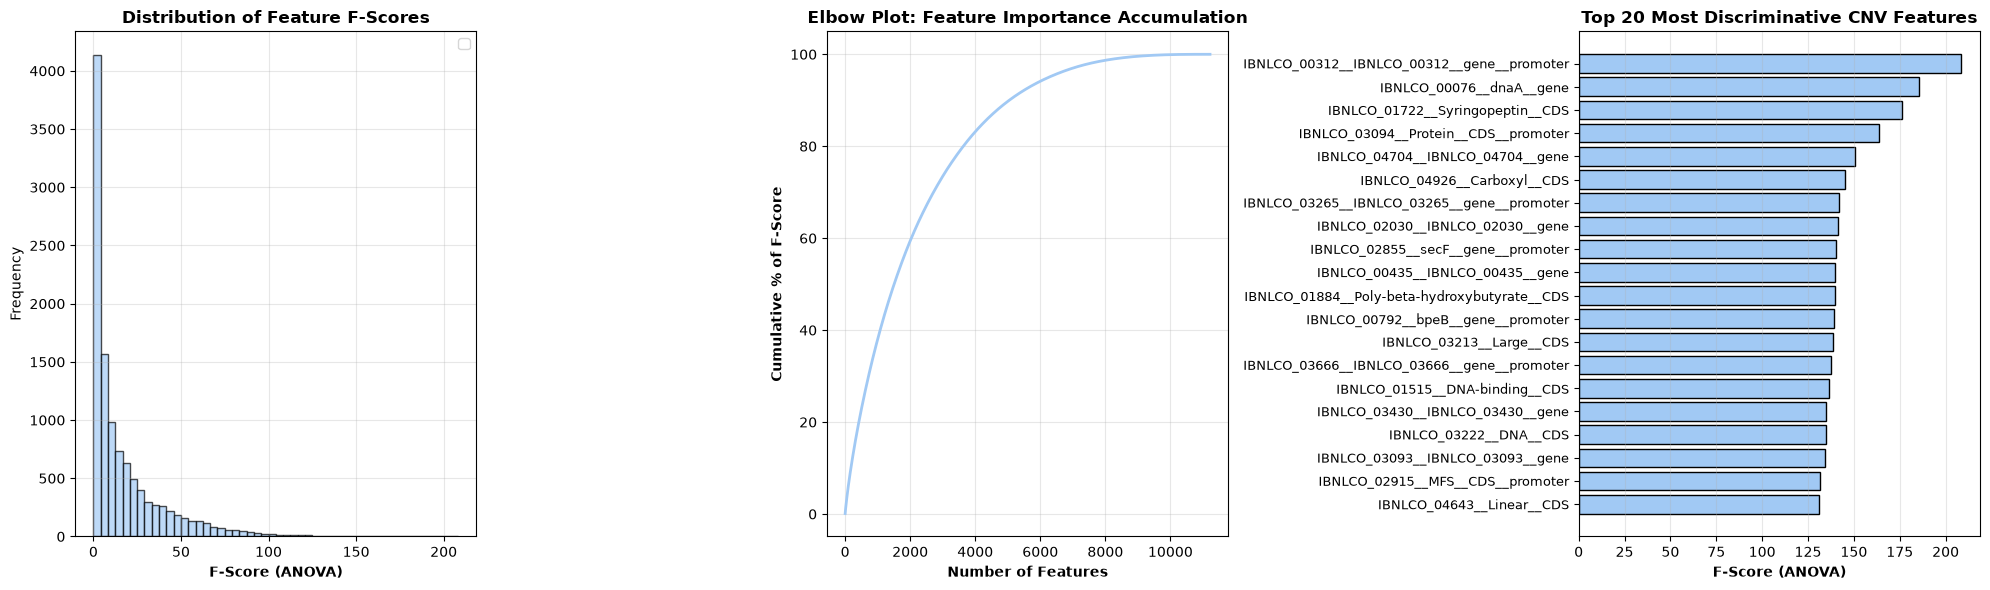

In [27]:
# Visualize top features and selection
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Distribution of F-scores
ax = axes[0]
ax.hist(feature_importance['f_score'], bins=50, alpha=0.7, edgecolor="black")
ax.set_xlabel("F-Score (ANOVA)", fontweight='bold')
ax.set_ylabel("Frequency")
ax.set_title("Distribution of Feature F-Scores", fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)

# Elbow plot
cumsum_scores = np.cumsum(feature_importance['f_score'].values)
cumsum_scores_pct = 100 * cumsum_scores / cumsum_scores[-1]
print(cumsum_scores)
ax = axes[1]
ax.plot(range(1, len(cumsum_scores_pct)+1), cumsum_scores_pct, linewidth=2)
ax.set_xlabel('Number of Features', fontweight='bold')
ax.set_ylabel('Cumulative % of F-Score', fontweight='bold')
ax.set_title('Elbow Plot: Feature Importance Accumulation', fontweight='bold')
ax.grid(alpha=0.3)

# Top 20 features
ax = axes[2]
top20 = feature_importance.head(20).sort_values('f_score')
bars = ax.barh(range(len(top20)), top20['f_score'], edgecolor='black', linewidth=1)
ax.set_yticks(range(len(top20)))
ax.set_yticklabels([f.replace('cnv_depth__', '') for f in top20['cnv_feature']], fontsize=9)
ax.set_xlabel('F-Score (ANOVA)', fontweight='bold')
ax.set_title(f'Top 20 Most Discriminative CNV Features', fontweight='bold')
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig("Figures/02_feature_selection_selectkbest.png", dpi=300, bbox_inches='tight')
plt.show()

## **3. Save the feature matrix**

In [26]:
# Save cleaned data for ML
cnv_selected_df.to_csv(f'cnvs_cleaned_{target_antibiotic}.csv')
print(f"Saved selected features to: cnvs_cleaned_{target_antibiotic}.csv")

# Save target variable
SXT_profile.to_csv(f'{target_antibiotic}.csv')

# Save feature rankings
feature_importance.to_csv(f'feature_rankings_{target_antibiotic}.csv', index=False)
print(f"Saved feature rankings to: feature_rankings_{target_antibiotic}.csv")

print(f'\nFinal feature matrix:')
print(f'Samples: {cnv_selected_df.shape[0]}')
print(f'Features: {cnv_selected_df.shape[1]}')

Saved selected features to: cnvs_cleaned_SXT.csv
Saved feature rankings to: feature_rankings_SXT.csv

Final feature matrix:
Samples: 221
Features: 7197
